In [ ]:
1from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Data Exploration

* Analyze dataset structure and class distribution

In [ ]:
import pandas as pd
import os

# Path to extracted data
data_path = "/content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master"
meta_file = os.path.join(data_path, "meta", "esc50.csv")

# Load metadata
esc50_df = pd.read_csv(meta_file)
esc50_df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


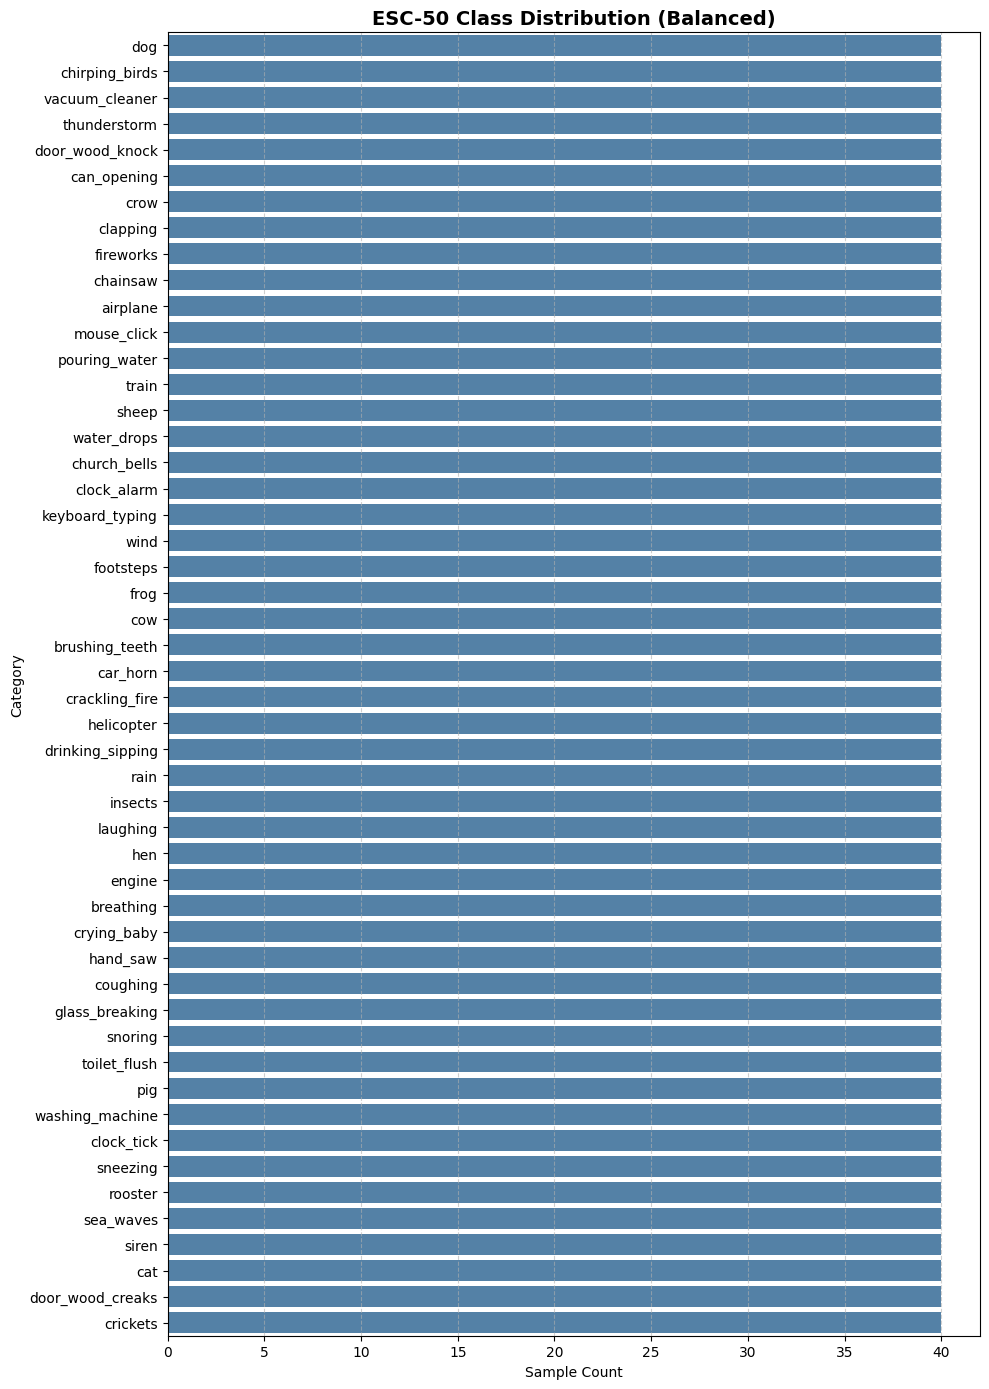

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 14))

# Horizontal plot for better readability
sns.countplot(
    data=esc50_df,
    y='category',
    color='steelblue',
    order=esc50_df['category'].value_counts().index
)

plt.title("ESC-50 Class Distribution (Balanced)", fontsize=14, fontweight='bold')
plt.xlabel("Sample Count")
plt.ylabel("Category")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import librosa

audio_dir = os.path.join(data_path, "audio")

# Extract Audio Properties

# Get the full path of the first audio file in the metadata list
sample_file = os.path.join(audio_dir, esc50_df.iloc[0]['filename'])
y, sr = librosa.load(sample_file, sr=None)
duration = librosa.get_duration(y=y, sr=sr)

# Generate Table for Report
print(f"{'Property':<25} | {'Value'}")
print("-" * 45)
print(f"{'Total Audio Files':<25} | {len(esc50_df)}")
print(f"{'Total Categories':<25} | {esc50_df['category'].nunique()}")
print(f"{'Sampling Rate':<25} | {sr} Hz")
print(f"{'Duration per Clip':<25} | {duration:.1f} seconds")
print(f"{'Bit Depth (Internal)':<25} | {y.dtype}")
print(f"{'Audio Channels':<25} | {'Mono' if y.ndim == 1 else 'Stereo'}")

Property                  | Value
---------------------------------------------
Total Audio Files         | 2000
Total Categories          | 50
Sampling Rate             | 44100 Hz
Duration per Clip         | 5.0 seconds
Bit Depth (Internal)      | float32
Audio Channels            | Mono


* Visualize Waveform

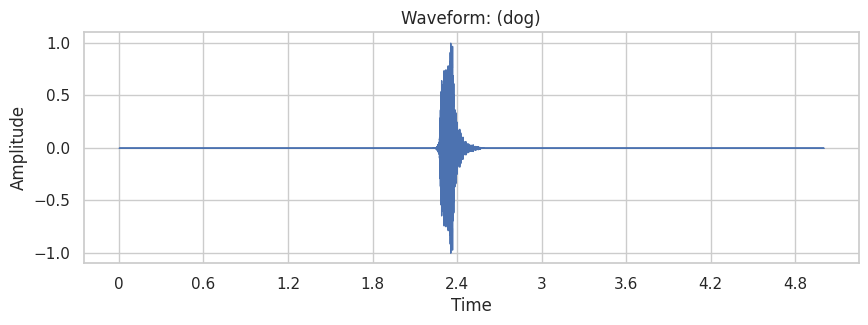

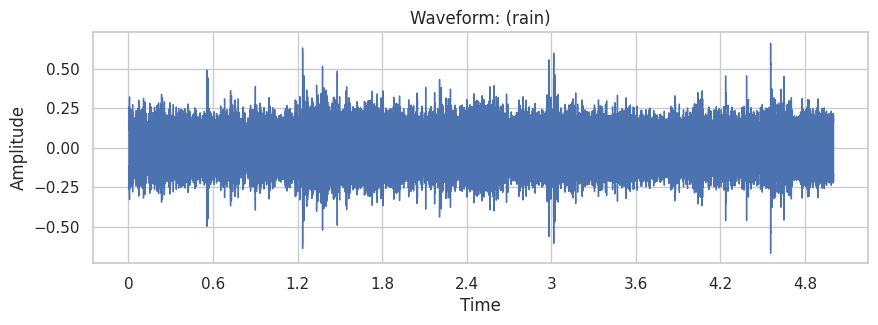

In [ ]:
import librosa.display #librosa.display is an open source python library used for audio and music signal analysis

def plot_waveform(category):
    # Filter using the esc50_df
    filename = esc50_df[esc50_df['category'] == category].iloc[0]['filename']

    # Updated path to look in your Google Drive folder
    path = os.path.join(audio_dir, filename)

    # Load audio
    y, sr = librosa.load(path, sr=None)

    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(y, sr=sr)
    plt.title(f"Waveform: ({category})")
    plt.ylabel("Amplitude")
    plt.show()

# Run the plots
plot_waveform('dog')
plot_waveform('rain')

* Mel Spectogram

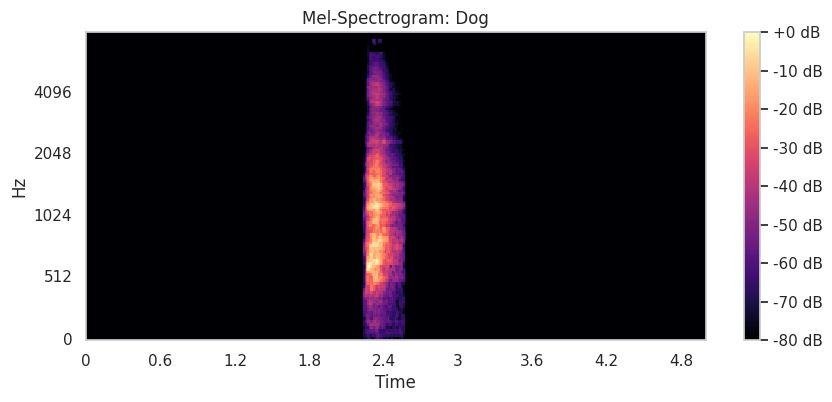

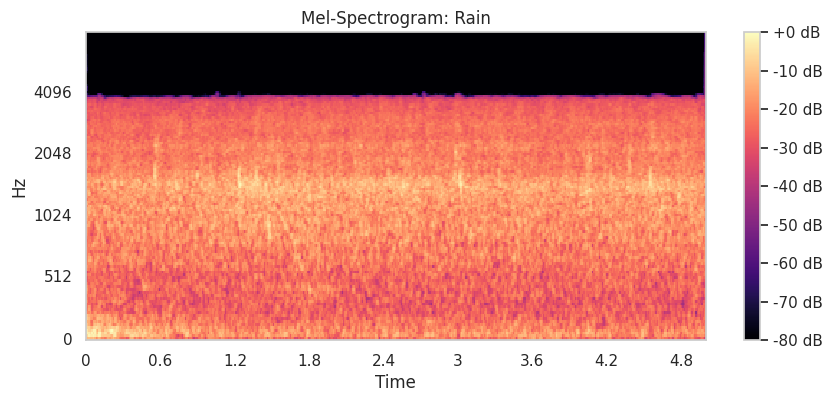

In [ ]:
import numpy as np

def plot_mel_spec(category):
    filename = esc50_df[esc50_df['category'] == category].iloc[0]['filename']
    path = os.path.join(audio_dir, filename)
    y, sr = librosa.load(path, sr=None)

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr, fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel-Spectrogram: {category.capitalize()}")
    plt.show()

plot_mel_spec('dog')
plot_mel_spec('rain')

* Loudness Variability Analysis

Processing 2000 files... this will take a few minutes.


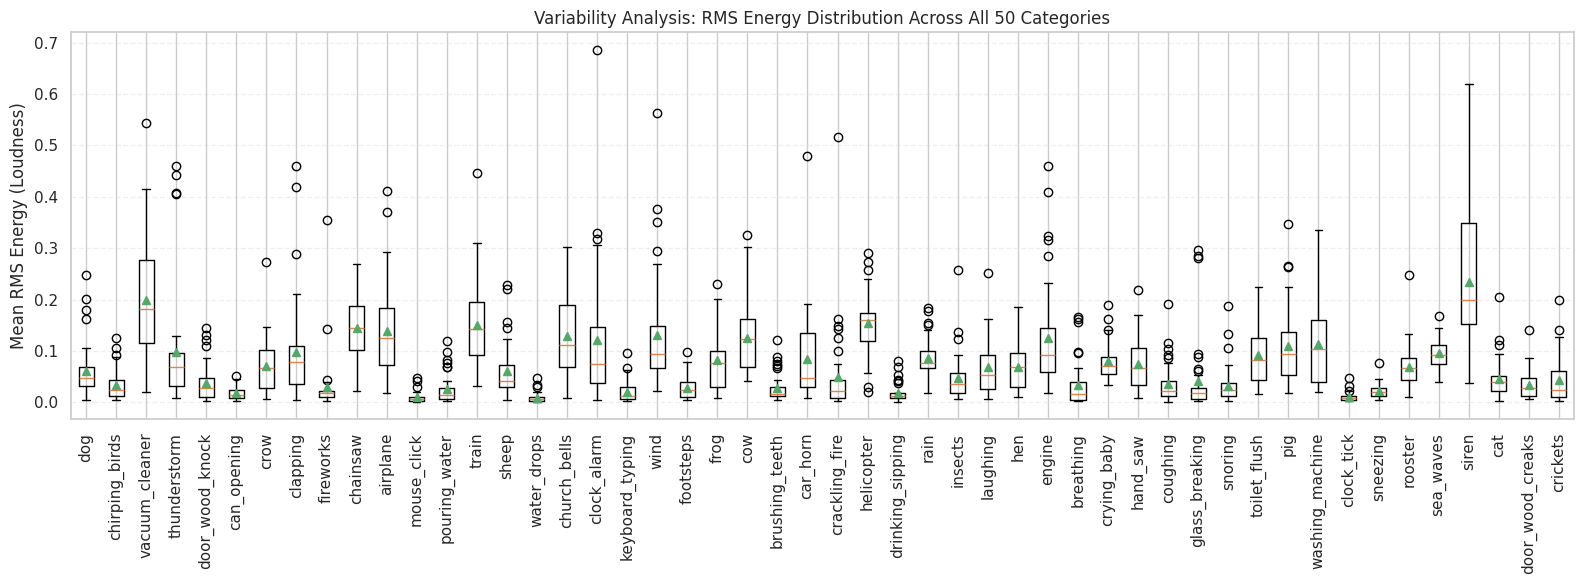

In [ ]:
# Create a list of results in the same order as the category names
categories = esc50_df['category'].unique()
data_to_plot = []

print("Processing 2000 files... this will take a few minutes.")

for category in categories:
    # Get all filenames for this category
    category_files = esc50_df[esc50_df['category'] == category]['filename']
    rms_list = []

    for file in category_files:
        path = os.path.join(audio_dir, file)
        # We only need the audio data (y), sr=None keeps original 44.1kHz
        y, _ = librosa.load(path, sr=None)
        rms = librosa.feature.rms(y=y)
        rms_list.append(np.mean(rms))

    data_to_plot.append(rms_list)

# Boxplot to show variability
plt.figure(figsize=(16, 6))
plt.boxplot(data_to_plot, tick_labels=categories, showmeans=True)
plt.xticks(rotation=90)
plt.title("Variability Analysis: RMS Energy Distribution Across All 50 Categories")
plt.ylabel("Mean RMS Energy (Loudness)")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

* Normalization check

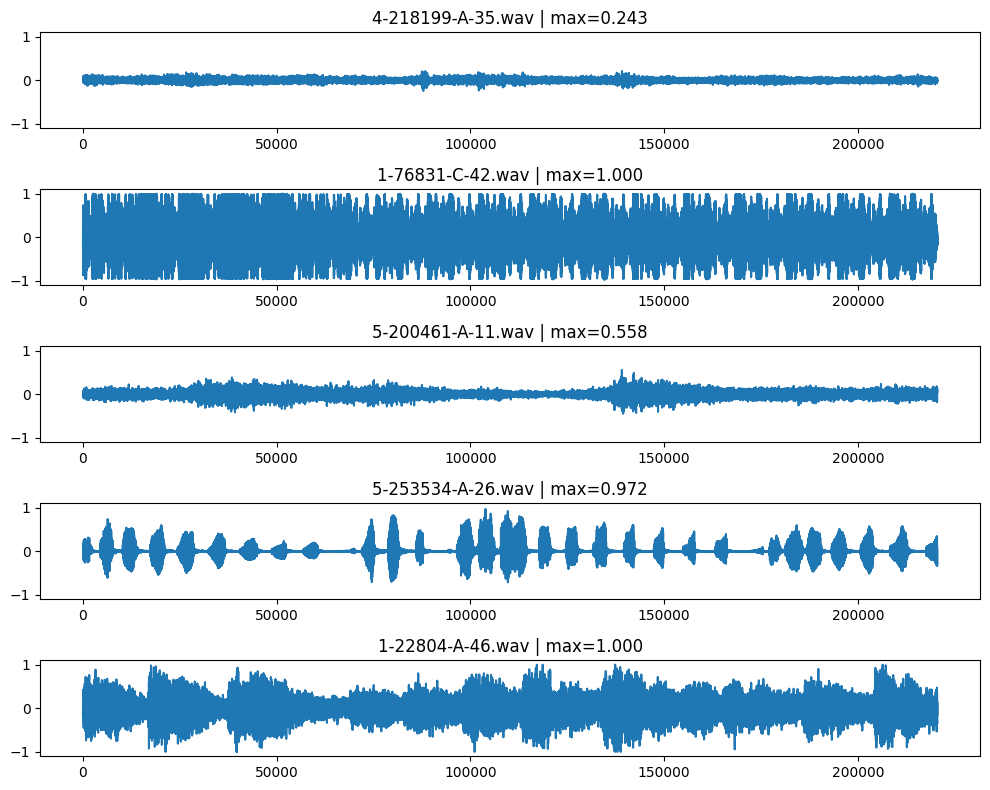

In [ ]:
files = os.listdir(audio_dir)[:5]

fig, axes = plt.subplots(len(files), 1, figsize=(10, 8))

for i, f in enumerate(files):
    y, sr = librosa.load(os.path.join(audio_dir, f), sr=None)
    axes[i].plot(y)
    axes[i].set_title(f"{f} | max={np.max(np.abs(y)):.3f}")
    axes[i].set_ylim(-1.1, 1.1)

plt.tight_layout()
plt.show()